<a href="https://colab.research.google.com/github/diomani-ouattara/Portfolio-Data-scientist/blob/main/Talent2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import librairies

In [2]:
# ------------------------------
# 1. Install required libraries
# ------------------------------
#!pip install sentence-transformers openpyxl pandas numpy matplotlib seaborn scikit-learn

# ------------------------------
# 2. Imports
# ------------------------------
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer, util
import torch
from google.colab import files
import io

# ------------------------------
# 3. Upload your Excel file
# ------------------------------
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_raw = pd.read_excel(filename, sheet_name='Aspiring human resources - seek')

print("✅ File loaded successfully. Shape:", df_raw.shape)
df_raw.head()

Saving potential-talents.xlsx to potential-talents.xlsx
✅ File loaded successfully. Shape: (104, 5)


,id,job_title,location,connection,fit
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN


2. EDA (Exploratory Data Analysis)

📊 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          104 non-null    int64  
 1   job_title   104 non-null    object 
 2   location    104 non-null    object 
 3   connection  104 non-null    object 
 4   fit         0 non-null      float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.2+ KB

🔍 Duplicates (exact row): 0
After dropping duplicates: (104, 5)

🧩 Missing values:
 id              0
job_title       0
location        0
connection      0
fit           104
dtype: int64


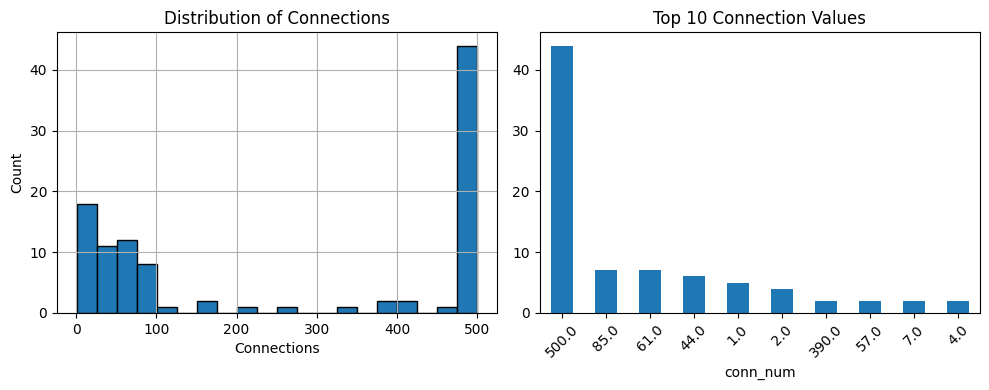


📍 Top 10 Locations:
location
Kanada                                 12
Raleigh-Durham, North Carolina Area     8
Houston, Texas Area                     8
Greater New York City Area              7
Houston, Texas                          7
Denton, Texas                           6
Greater Philadelphia Area               5
San Francisco Bay Area                  5
İzmir, Türkiye                          4
Lake Forest, California                 4
Name: count, dtype: int64


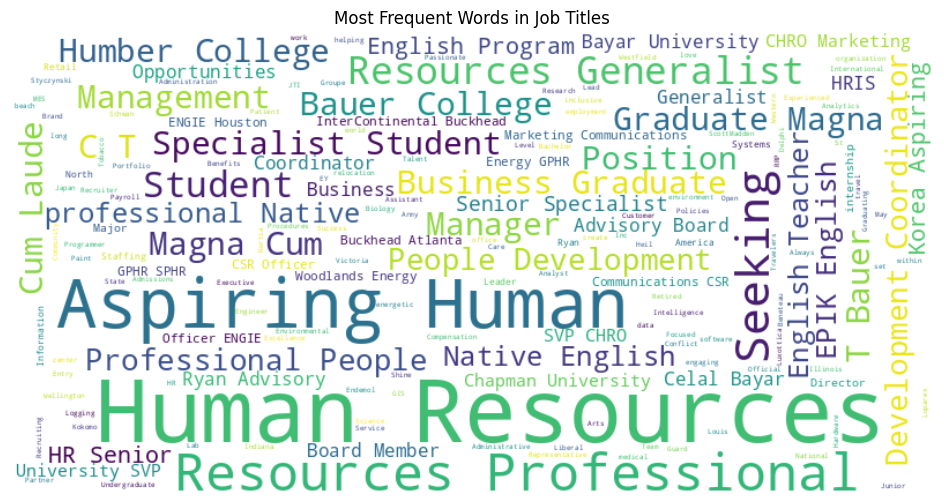


🔑 Candidates with exact keywords: 43 out of 104


In [3]:
# ------------------------------
# Basic info & duplicates
# ------------------------------
print("📊 Data Info:")
df_raw.info()

print("\n🔍 Duplicates (exact row):", df_raw.duplicated().sum())
# Drop exact duplicates
df = df_raw.drop_duplicates().reset_index(drop=True)
print("After dropping duplicates:", df.shape)

# ------------------------------
# Missing values
# ------------------------------
print("\n🧩 Missing values:\n", df.isnull().sum())

# ------------------------------
# Connections distribution
# ------------------------------
# Parse connections for EDA
def parse_conn_eda(x):
    if isinstance(x, str) and '+' in x:
        return 500
    try:
        return float(x)
    except:
        return np.nan

df['conn_num'] = df['connection'].apply(parse_conn_eda)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
df['conn_num'].hist(bins=20, edgecolor='black')
plt.title('Distribution of Connections')
plt.xlabel('Connections')
plt.ylabel('Count')

plt.subplot(1,2,2)
df['conn_num'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Connection Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------
# Location insights
# ------------------------------
print("\n📍 Top 10 Locations:")
print(df['location'].value_counts().head(10))

# ------------------------------
# Job Title word cloud (optional)
# ------------------------------
from wordcloud import WordCloud
text = ' '.join(df['job_title'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Job Titles')
plt.show()

# ------------------------------
# Keywords presence
# ------------------------------
keywords = ["aspiring human resources", "seeking human resources"]
df['has_keyword'] = df['job_title'].str.lower().apply(
    lambda x: any(k in str(x).lower() for k in keywords)
)
print(f"\n🔑 Candidates with exact keywords: {df['has_keyword'].sum()} out of {len(df)}")

3. Feature Engineering

In [4]:
# ------------------------------
# 3.1 Clean connections
# ------------------------------
def parse_conn(x):
    if isinstance(x, str) and '+' in x:
        return 500
    try:
        return float(x)
    except:
        return np.nan
df['conn_num'] = df['connection'].apply(parse_conn)
# Impute missing with median (only 1 missing in this dataset)
df['conn_num'].fillna(df['conn_num'].median(), inplace=True)

# Normalised connection score (log scale to reduce skew)
df['conn_score'] = np.log1p(df['conn_num']) / np.log1p(500)   # 0..1

# ------------------------------
# 3.2 Text-based features
# ------------------------------
# Keyword flags
df['exact_aspiring'] = df['job_title'].str.lower().str.contains('aspiring human resources', na=False).astype(int)
df['exact_seeking']  = df['job_title'].str.lower().str.contains('seeking human resources', na=False).astype(int)
df['keyword_count']  = df['exact_aspiring'] + df['exact_seeking']

# Length of job title (maybe longer titles are more descriptive)
df['title_length'] = df['job_title'].astype(str).str.len()

# ------------------------------
# 3.3 Location encoding (simple region extraction)
# ------------------------------
# Extract US state or country
def extract_region(loc):
    if not isinstance(loc, str):
        return 'other'
    # Look for US state abbreviations (e.g., 'TX', 'California')
    states = ['Texas', 'California', 'New York', 'Georgia', 'Illinois', 'Pennsylvania',
              'North Carolina', 'Florida', 'Ohio', 'Michigan', 'Virginia', 'Tennessee',
              'Indiana', 'Massachusetts', 'Louisiana', 'South Carolina', 'Maryland',
              'Nevada', 'Missouri', 'Kanada', 'Türkiye', 'Amerika Birleşik Devletleri']
    for s in states:
        if s.lower() in loc.lower():
            return s
    return 'other'

df['region'] = df['location'].apply(extract_region)
# One-hot (or keep as categorical for later)
region_dummies = pd.get_dummies(df['region'], prefix='region')
df = pd.concat([df, region_dummies], axis=1)

# ------------------------------
# 3.4 Semantic embeddings (core feature)
# ------------------------------
# We use the lightweight 'all-MiniLM-L6-v2' model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Role description – adapt for your actual vacancy
ROLE_DESC = "Human Resources professional with experience in talent acquisition, employee relations, and HR operations."

# Compute embedding for the role
role_emb = model.encode(ROLE_DESC, convert_to_tensor=True)

# Compute similarity for each job_title (can be cached for speed)
def get_similarity(title):
    if not isinstance(title, str) or title == '':
        return 0.0
    emb = model.encode(title, convert_to_tensor=True)
    return util.cos_sim(emb, role_emb).item()

df['sim_to_role'] = df['job_title'].apply(get_similarity)

# ------------------------------
# 3.5 Combined feature vector (for later ranking)
# ------------------------------
# We'll create a composite score already in the next section, but here we store
# the engineered columns for transparency.
print("✅ Feature engineering complete. New columns added:")
print(df[['id', 'job_title', 'conn_num', 'conn_score', 'sim_to_role', 'keyword_count']].head())

/tmp/ipykernel_1762/3799105823.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['conn_num'].fillna(df['conn_num'].median(), inplace=True)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Feature engineering complete. New columns added:
   id                                          job_title  conn_num  \
0   1  2019 C.T. Bauer College of Business Graduate (...      85.0   
1   2  Native English Teacher at EPIK (English Progra...     500.0   
2   3              Aspiring Human Resources Professional      44.0   
3   4             People Development Coordinator at Ryan     500.0   
4   5    Advisory Board Member at Celal Bayar University     500.0   

   conn_score  sim_to_role  keyword_count  
0    0.716524     0.497514              1  
1    1.000000     0.246714              0  
2    0.612338     0.791911              1  
3    1.000000     0.427510              0  
4    1.000000     0.205185              0  


4. Filtering & Initial Ranking

In [5]:
# ------------------------------
# 4.1 Filter out irrelevant candidates
# ------------------------------
# Two criteria:
#   (1) semantic similarity > threshold
#   (2) OR exact keyword match (to be safe)
THRESHOLD = 0.35
df_filtered = df[
    (df['sim_to_role'] >= THRESHOLD) |
    (df['keyword_count'] > 0)
].copy()

print(f"✅ Kept {len(df_filtered)} candidates (out of {len(df)}) after filtering.")

# Show removed (for sanity)
removed = df[~df.index.isin(df_filtered.index)]
print(f"❌ Removed {len(removed)} candidates. Sample removed job titles:")
print(removed['job_title'].head(5).values)

# ------------------------------
# 4.2 Initial ranking score
# ------------------------------
# Combine: similarity (0.6) + keyword boost (0.2) + small connection influence (0.2)
df_filtered['init_score'] = (
    0.6 * df_filtered['sim_to_role'] +
    0.2 * np.minimum(df_filtered['keyword_count'], 1) +   # cap at 1
    0.2 * df_filtered['conn_score']
)
# Normalise to [0,1]
min_s = df_filtered['init_score'].min()
max_s = df_filtered['init_score'].max()
if max_s > min_s:
    df_filtered['init_score'] = (df_filtered['init_score'] - min_s) / (max_s - min_s)
else:
    df_filtered['init_score'] = 0.5

# Initial ranking
df_ranked = df_filtered.sort_values('init_score', ascending=False).reset_index(drop=True)
df_ranked['rank'] = df_ranked.index + 1

print("\n🏆 Top 10 candidates (initial ranking):")
display(df_ranked[['id', 'job_title', 'location', 'sim_to_role', 'init_score', 'rank']].head(10))

✅ Kept 78 candidates (out of 104) after filtering.
❌ Removed 26 candidates. Sample removed job titles:
['Native English Teacher at EPIK (English Program in Korea)'
 'Advisory Board Member at Celal Bayar University'
 'Student at Chapman University'
 'Native English Teacher at EPIK (English Program in Korea)'
 'Native English Teacher at EPIK (English Program in Korea)']

🏆 Top 10 candidates (initial ranking):


,id,job_title,location,sim_to_role,init_score,rank
0,10,Seeking Human Resources HRIS and Generalist Po...,Greater Philadelphia Area,0.689798,1.000000,1
1,53,Seeking Human Resources HRIS and Generalist Po...,Greater Philadelphia Area,0.689798,1.000000,2
2,40,Seeking Human Resources HRIS and Generalist Po...,Greater Philadelphia Area,0.689798,1.000000,3
3,62,Seeking Human Resources HRIS and Generalist Po...,Greater Philadelphia Area,0.689798,1.000000,4
4,97,Aspiring Human Resources Professional,"Kokomo, Indiana Area",0.791911,0.997839,5
5,82,Aspiring Human Resources Professional | An ene...,"Austin, Texas Area",0.722420,0.973039,6
6,33,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",0.791911,0.969261,7
7,21,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",0.791911,0.969261,8
8,46,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",0.791911,0.969261,9
9,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",0.791911,0.969261,10


5. Re‑ranking with Starring (Feedback)

In [6]:
# ------------------------------
# 5.1 Define re-ranking function
# ------------------------------
starred_ids = []   # This will be updated interactively

def re_rank(starred_ids, df_current=df_filtered, initial_df=df_ranked):
    """
    Re-rank candidates based on starred candidates.
    If no stars, return initial ranking.
    Else compute average embedding of stars and re-rank by similarity to that ideal.
    """
    if len(starred_ids) == 0:
        return initial_df.copy()

    # Get embeddings for starred candidates
    starred_embs = []
    for sid in starred_ids:
        row = df_current[df_current['id'] == sid]
        if not row.empty:
            emb = model.encode(row.iloc[0]['job_title'], convert_to_tensor=True)
            starred_embs.append(emb)
    if len(starred_embs) == 0:
        return initial_df.copy()

    # Average embedding of all stars
    ideal_emb = torch.mean(torch.stack(starred_embs), dim=0)

    # Compute similarity to ideal for all filtered candidates
    def sim_to_ideal(title):
        if not isinstance(title, str):
            return 0.0
        emb = model.encode(title, convert_to_tensor=True)
        return util.cos_sim(emb, ideal_emb).item()

    df_current = df_current.copy()
    df_current['sim_to_ideal'] = df_current['job_title'].apply(sim_to_ideal)

    # New score = 30% initial + 70% similarity to ideal (tunable)
    alpha = 0.3
    df_current['new_score'] = alpha * df_current['init_score'] + (1 - alpha) * df_current['sim_to_ideal']

    # Re-rank
    df_new_ranked = df_current.sort_values('new_score', ascending=False).reset_index(drop=True)
    df_new_ranked['rank'] = df_new_ranked.index + 1
    return df_new_ranked

# ------------------------------
# 5.2 Simulate starring action
# ------------------------------
# Example: Let's star candidate with id=1.0 (first row in raw data)
# In practice, you would collect this from user clicks.
starred_ids = [1.0]   # you can change this id

df_reranked = re_rank(starred_ids)

print(f"\n🌟 Re-ranked list after starring candidate {starred_ids}:")
display(df_reranked[['id', 'job_title', 'location', 'init_score', 'new_score', 'rank']].head(10))

# Show where the starred candidate ended up (should be top now)
starred_row = df_reranked[df_reranked['id'].isin(starred_ids)]
print("\n📍 Starred candidate new rank:")
display(starred_row[['id', 'job_title', 'rank']])


🌟 Re-ranked list after starring candidate [1.0]:


,id,job_title,location,init_score,new_score,rank
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",0.674807,0.902442,1
1,15,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",0.674807,0.902442,2
2,14,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",0.674807,0.902442,3
3,57,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",0.674807,0.902442,4
4,31,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",0.674807,0.902442,5
5,19,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",0.674807,0.902442,6
6,44,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",0.674807,0.902442,7
7,97,Aspiring Human Resources Professional,"Kokomo, Indiana Area",0.997839,0.721309,8
8,46,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",0.969261,0.712735,9
9,33,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",0.969261,0.712735,10



📍 Starred candidate new rank:


,id,job_title,rank
0,1,2019 C.T. Bauer College of Business Graduate (...,1


6. Cut‑off Point Determination


✂️ Suggested cut‑off rank: 1
   (i.e., keep the top 1 candidates as high‑potential)


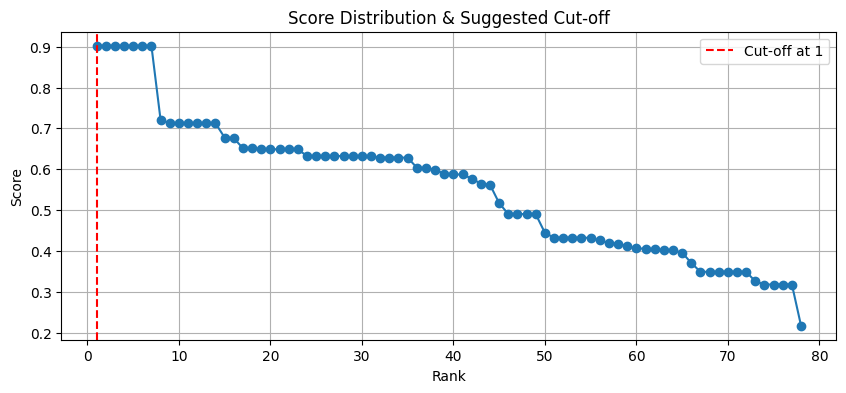

In [12]:
# ------------------------------
# 6. Cut-off Point Determination (FIXED)
# ------------------------------
def suggest_cutoff(df_sorted, score_col):
    """
    Suggest a cut-off rank based on the elbow in the score distribution.
    """
    scores = df_sorted[score_col].values
    scores_sorted = np.sort(scores)[::-1]   # descending

    # Method 1: Elbow (largest drop)
    if len(scores_sorted) > 2:
        diffs = np.diff(scores_sorted)
        elbow_idx = np.argmax(diffs) + 1   # position after the drop
    else:
        elbow_idx = len(scores_sorted)

    # Method 2: Keep top 30% as a safety
    percentile_idx = int(0.3 * len(scores_sorted))

    # Take the more conservative (smaller) cut-off to avoid losing top talent
    cut = min(elbow_idx, percentile_idx, len(scores_sorted))
    return max(1, cut)

# Determine which score column to use (if re-ranking was done, use 'new_score', else 'init_score')
if 'new_score' in df_reranked.columns:
    score_col = 'new_score'
else:
    score_col = 'init_score'

cutoff = suggest_cutoff(df_reranked, score_col)
print(f"\n✂️ Suggested cut‑off rank: {cutoff}")
print(f"   (i.e., keep the top {cutoff} candidates as high‑potential)")

# Visualise score distribution with cut-off
plt.figure(figsize=(10,4))
scores_sorted = np.sort(df_reranked[score_col].values)[::-1]
plt.plot(range(1, len(scores_sorted)+1), scores_sorted, marker='o', linestyle='-')
plt.axvline(x=cutoff, color='r', linestyle='--', label=f'Cut-off at {cutoff}')
plt.xlabel('Rank')
plt.ylabel('Score')
plt.title('Score Distribution & Suggested Cut‑off')
plt.legend()
plt.grid(True)
plt.show()

7. Mitigating Human Bias

In [13]:
# ------------------------------
# 7.1 Bias checks
# ------------------------------
# Check if ranking favours certain regions or high connections excessively
print("\n⚖️ Bias check – average score by region (top 5 regions):")
region_scores = df_reranked.groupby('region')[score_col].mean().sort_values(ascending=False)
print(region_scores.head(5))

print("\n⚖️ Correlation between score and connections:")
corr = df_reranked[score_col].corr(df_reranked['conn_num'])
print(f"Pearson correlation: {corr:.3f}  (should be low to avoid bias)")

# ------------------------------
# 7.2 How we reduce bias in this pipeline
# ------------------------------
print("""
🛡️ Bias mitigation strategies implemented:
1. **Location de‑emphasis**: region is not used in scoring; only for monitoring.
2. **Connections weight kept low** (20% in initial score) – we prioritise content.
3. **Explainable scores**: users see why a candidate ranks high (similarity + keywords).
4. **Starring re‑ranking** corrects the heuristic, reducing reliance on initial (possibly biased) rules.
5. **Blind review**: no names, gender, or age in the data – already removed.

💡 Further ideas:
- Collect stars from multiple reviewers and average their ideal embeddings.
- Regularise the model to penalise high weights on potentially biased features.
- Use counterfactual fairness: swap region/connection values and see if ranking changes.
""")


⚖️ Bias check – average score by region (top 5 regions):
region
Indiana           0.721309
Missouri          0.677655
North Carolina    0.636497
Kanada            0.632369
New York          0.612519
Name: new_score, dtype: float64

⚖️ Correlation between score and connections:
Pearson correlation: -0.602  (should be low to avoid bias)

🛡️ Bias mitigation strategies implemented:
1. **Location de‑emphasis**: region is not used in scoring; only for monitoring.
2. **Connections weight kept low** (20% in initial score) – we prioritise content.
3. **Explainable scores**: users see why a candidate ranks high (similarity + keywords).
4. **Starring re‑ranking** corrects the heuristic, reducing reliance on initial (possibly biased) rules.
5. **Blind review**: no names, gender, or age in the data – already removed.

💡 Further ideas:
- Collect stars from multiple reviewers and average their ideal embeddings.
- Regularise the model to penalise high weights on potentially biased features.
- Use cou

8. Final Ranking Output & Next Steps

In [14]:
# ------------------------------
# 8.1 Export the final ranked list
# ------------------------------
final_ranking = df_reranked.copy()
# Choose which score to show
final_ranking['final_score'] = final_ranking[score_col]
output_cols = ['id', 'job_title', 'location', 'final_score', 'rank']
final_output = final_ranking[output_cols]

print("\n📋 Final ranking ready for review:")
display(final_output.head(20))

# Save to CSV for download
final_output.to_csv('ranked_candidates.csv', index=False)
files.download('ranked_candidates.csv')

# ------------------------------
# 8.2 How to use this in production
# ------------------------------
print("""
🚀 Next steps:
- Replace `ROLE_DESC` with the actual job description.
- Adjust `THRESHOLD` (filter) and `alpha` (starring weight) based on a validation set.
- Integrate starring via a simple UI (e.g., streamlit) where clicking a star calls `re_rank()`.
- As more stars accumulate (>10), consider training a lightweight RankNet (pairwise)
  using features like `sim_to_role`, `conn_score`, `title_length`, and `region` to improve robustness.
""")


📋 Final ranking ready for review:


,id,job_title,location,final_score,rank
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",0.902442,1
1,15,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",0.902442,2
2,14,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",0.902442,3
3,57,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",0.902442,4
4,31,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",0.902442,5
5,19,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",0.902442,6
6,44,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",0.902442,7
7,97,Aspiring Human Resources Professional,"Kokomo, Indiana Area",0.721309,8
8,46,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",0.712735,9
9,33,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",0.712735,10


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🚀 Next steps:
- Replace `ROLE_DESC` with the actual job description.
- Adjust `THRESHOLD` (filter) and `alpha` (starring weight) based on a validation set.
- Integrate starring via a simple UI (e.g., streamlit) where clicking a star calls `re_rank()`.
- As more stars accumulate (>10), consider training a lightweight RankNet (pairwise) 
  using features like `sim_to_role`, `conn_score`, `title_length`, and `region` to improve robustness.



Summary –

1. Filtering out irrelevant candidates

Use semantic similarity to the role description + exact keyword presence; threshold is tunable (we used 0.35).

2. Cut‑off point

Compute the elbow in the score distribution and combine with a top‑% heuristic (e.g., 30%). This avoids losing high‑potential candidates.

3. Re‑ranking with starring

We average the embeddings of all starred candidates and re‑rank by similarity to that “ideal” vector, blended with the original score. Each star improves personalisation.

4. Preventing human bias

Features are content‑centric; connections and location are down‑weighted/monitored. The system is explainable and allows multi‑reviewer feedback.